# Data bilan tanishuv 

In [83]:
import pandas as pd 
df=pd.read_csv('paris_housing_prices_dataset.csv')

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            1200 non-null   str    
 1   Arrondissement         1200 non-null   int64  
 2   Property_Type          1200 non-null   str    
 3   Size_sqm               1200 non-null   int64  
 4   Rooms                  1200 non-null   int64  
 5   Floor                  1200 non-null   int64  
 6   Year_Built             1200 non-null   int64  
 7   Condition              1200 non-null   str    
 8   Distance_to_Center_km  1200 non-null   float64
 9   Price_EUR              1200 non-null   float64
dtypes: float64(2), int64(5), str(3)
memory usage: 93.9 KB


In [85]:
df.isnull().sum()

Property_ID              0
Arrondissement           0
Property_Type            0
Size_sqm                 0
Rooms                    0
Floor                    0
Year_Built               0
Condition                0
Distance_to_Center_km    0
Price_EUR                0
dtype: int64

In [86]:
df.sample(5)

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
439,P10439,3,Loft,114,5,2,1996,Needs Renovation,14.66,1659814.77
1148,P11148,14,Loft,78,5,9,1869,Renovated,12.39,1166502.54
26,P10026,3,Studio,66,4,1,1980,Renovated,4.86,727411.58
1125,P11125,11,Penthouse,101,2,4,1997,Needs Renovation,12.84,876131.25
992,P10992,9,Studio,137,5,6,1897,New,8.97,1743136.80


# Preprocessing

In [87]:
from sklearn.preprocessing import LabelEncoder
def encodla(df):
    encoder=LabelEncoder()
    for col in df.columns:
        if df[col].dtype=='str':
            if df[col].nunique()<=5:
                dummies=pd.get_dummies(df[col],prefix=col,dtype=int)
                df=pd.concat([df.drop(columns=col),dummies],axis=1)
            else:
                df[col]=encoder.fit_transform(df[col])
    return df

In [88]:
df=encodla(df)

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Property_ID                 1200 non-null   int64  
 1   Arrondissement              1200 non-null   int64  
 2   Size_sqm                    1200 non-null   int64  
 3   Rooms                       1200 non-null   int64  
 4   Floor                       1200 non-null   int64  
 5   Year_Built                  1200 non-null   int64  
 6   Distance_to_Center_km       1200 non-null   float64
 7   Price_EUR                   1200 non-null   float64
 8   Property_Type_Apartment     1200 non-null   int64  
 9   Property_Type_Loft          1200 non-null   int64  
 10  Property_Type_Penthouse     1200 non-null   int64  
 11  Property_Type_Studio        1200 non-null   int64  
 12  Condition_Good              1200 non-null   int64  
 13  Condition_Needs Renovation  1200 non-null   

In [90]:
df.drop('Property_ID', axis=1, inplace=True)

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Arrondissement              1200 non-null   int64  
 1   Size_sqm                    1200 non-null   int64  
 2   Rooms                       1200 non-null   int64  
 3   Floor                       1200 non-null   int64  
 4   Year_Built                  1200 non-null   int64  
 5   Distance_to_Center_km       1200 non-null   float64
 6   Price_EUR                   1200 non-null   float64
 7   Property_Type_Apartment     1200 non-null   int64  
 8   Property_Type_Loft          1200 non-null   int64  
 9   Property_Type_Penthouse     1200 non-null   int64  
 10  Property_Type_Studio        1200 non-null   int64  
 11  Condition_Good              1200 non-null   int64  
 12  Condition_Needs Renovation  1200 non-null   int64  
 13  Condition_New               1200 non-null   

In [92]:
from sklearn.preprocessing import MinMaxScaler

In [93]:
def scaling_qil(df):
    scaler=MinMaxScaler()
    num_col = df.select_dtypes(include=['int64','float64']).columns
    df[num_col]=scaler.fit_transform(df[num_col]) 
    return df

In [94]:
df=scaling_qil(df)

In [95]:
df.sample(8)

,Arrondissement,Size_sqm,Rooms,Floor,Year_Built,Distance_to_Center_km,Price_EUR,Property_Type_Apartment,Property_Type_Loft,Property_Type_Penthouse,Property_Type_Studio,Condition_Good,Condition_Needs Renovation,Condition_New,Condition_Renovated
1002,0.368421,0.527174,1.00,0.888889,0.728324,0.248619,0.436388,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
760,0.473684,0.875000,0.25,1.000000,0.109827,0.249309,0.852843,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
364,0.368421,0.657609,0.25,0.333333,0.803468,0.474448,0.389872,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1122,0.473684,0.141304,0.25,0.888889,0.416185,0.859116,0.070847,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
116,0.421053,0.500000,0.25,0.222222,0.843931,0.822514,0.393796,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
841,0.894737,0.146739,0.50,1.000000,0.878613,0.061464,0.183801,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
928,0.473684,0.625000,0.00,0.111111,0.450867,0.357044,0.330272,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
446,0.947368,0.005435,0.00,0.555556,0.971098,0.989641,0.018514,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


# Train

In [96]:
X = df.drop(columns=['Price_EUR'])
y = df['Price_EUR']

In [97]:
from sklearn.model_selection import train_test_split

In [98]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Linear Model

In [99]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [100]:
y_pred = model.predict(X_test)

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.08477232001734754
MSE: 0.01165672708399554
R2: 0.7789811376387248


# Random forest

In [102]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.08477232001734754
MSE: 0.01165672708399554
R2: 0.7789811376387248


# Decision Tress

In [104]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [106]:
y_pred = model.predict(X_test)

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.10460644965096953
MSE: 0.021459491439603854
R2: 0.593114572327532


In [108]:
from tabulate import tabulate

result = [
    ['Logistic Regression',0.084,0.011,0.778],
    ['Random Forest',0.084,0.011,0.778],
    ['DecisionTreeRegressor',0.104,0.021,0.593]
]

headers = ['Algorithm', 'MAE','MSE','R2']

table = tabulate(result, headers=headers, tablefmt='grid')

print(table)

+-----------------------+-------+-------+-------+
| Algorithm             |   MAE |   MSE |    R2 |
+=======================+=======+=======+=======+
| Logistic Regression   | 0.084 | 0.011 | 0.778 |
+-----------------------+-------+-------+-------+
| Random Forest         | 0.084 | 0.011 | 0.778 |
+-----------------------+-------+-------+-------+
| DecisionTreeRegressor | 0.104 | 0.021 | 0.593 |
+-----------------------+-------+-------+-------+


In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Arrondissement              1200 non-null   float64
 1   Size_sqm                    1200 non-null   float64
 2   Rooms                       1200 non-null   float64
 3   Floor                       1200 non-null   float64
 4   Year_Built                  1200 non-null   float64
 5   Distance_to_Center_km       1200 non-null   float64
 6   Price_EUR                   1200 non-null   float64
 7   Property_Type_Apartment     1200 non-null   float64
 8   Property_Type_Loft          1200 non-null   float64
 9   Property_Type_Penthouse     1200 non-null   float64
 10  Property_Type_Studio        1200 non-null   float64
 11  Condition_Good              1200 non-null   float64
 12  Condition_Needs Renovation  1200 non-null   float64
 13  Condition_New               1200 non-null   

# Lasso/ridge

In [110]:
from sklearn.linear_model import  Lasso,Ridge

In [111]:
lasso=Lasso(alpha=0.1)

In [112]:
X = df.drop(columns=['Price_EUR'])
y = df['Price_EUR']

In [113]:
from sklearn.model_selection import train_test_split
lasso.fit(X_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [114]:
y_pred=lasso.predict(X_test)

In [115]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.19077181726389766
MSE: 0.05316225242656409
R2: -0.007989675593800705


# Ridge

In [116]:
ridge=Ridge(alpha=0.1)

In [117]:
ridge.fit(X_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [118]:
y_pred=ridge.predict(X_test)

In [119]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.08478984122298992
MSE: 0.011657475911993502
R2: 0.7789669393898492


In [120]:
from tabulate import tabulate

result = [
    ['Logistic Regression',0.084,0.011,0.778],
    ['Random Forest',0.084,0.011,0.778],
    ['DecisionTreeRegressor',0.104,0.021,0.593],
    ['Lasso',0.190,0.053,-0.007],
    ['Ridge',0.084,0.011,0.778]
]

headers = ['Algorithm','Lasso','Ridge', 'MAE','MSE','R2']

table = tabulate(result, headers=headers, tablefmt='grid')

print(table)

+-----------------------+---------+---------+--------+
| Algorithm             |   Lasso |   Ridge |    MAE |
+=======================+=========+=========+========+
| Logistic Regression   |   0.084 |   0.011 |  0.778 |
+-----------------------+---------+---------+--------+
| Random Forest         |   0.084 |   0.011 |  0.778 |
+-----------------------+---------+---------+--------+
| DecisionTreeRegressor |   0.104 |   0.021 |  0.593 |
+-----------------------+---------+---------+--------+
| Lasso                 |   0.19  |   0.053 | -0.007 |
+-----------------------+---------+---------+--------+
| Ridge                 |   0.084 |   0.011 |  0.778 |
+-----------------------+---------+---------+--------+


# Vizual ko'rinish

In [121]:
import pandas as pd 
df=pd.read_csv('paris_housing_prices_dataset.csv')

In [122]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            1200 non-null   str    
 1   Arrondissement         1200 non-null   int64  
 2   Property_Type          1200 non-null   str    
 3   Size_sqm               1200 non-null   int64  
 4   Rooms                  1200 non-null   int64  
 5   Floor                  1200 non-null   int64  
 6   Year_Built             1200 non-null   int64  
 7   Condition              1200 non-null   str    
 8   Distance_to_Center_km  1200 non-null   float64
 9   Price_EUR              1200 non-null   float64
dtypes: float64(2), int64(5), str(3)
memory usage: 93.9 KB


In [123]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'osish')

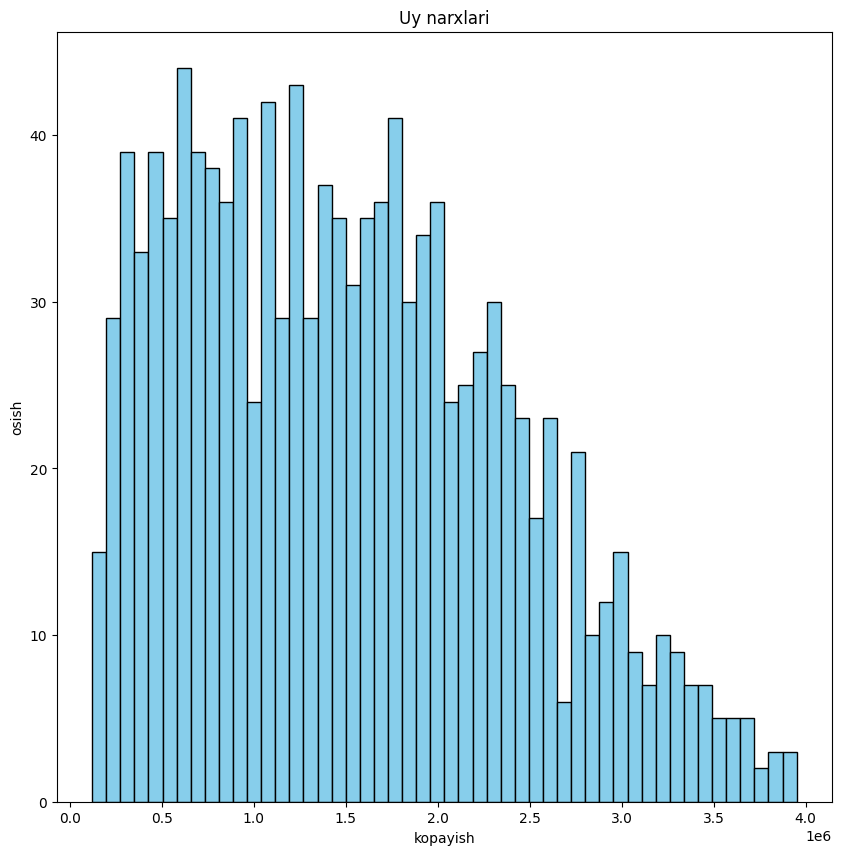

In [126]:
plt.figure(figsize=(10,10))
plt.hist(df['Price_EUR'],bins=50, color='skyblue',edgecolor='black')
plt.title('Uy narxlari')
plt.xlabel('kopayish')
plt.ylabel('osish')

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            1200 non-null   str    
 1   Arrondissement         1200 non-null   int64  
 2   Property_Type          1200 non-null   str    
 3   Size_sqm               1200 non-null   int64  
 4   Rooms                  1200 non-null   int64  
 5   Floor                  1200 non-null   int64  
 6   Year_Built             1200 non-null   int64  
 7   Condition              1200 non-null   str    
 8   Distance_to_Center_km  1200 non-null   float64
 9   Price_EUR              1200 non-null   float64
dtypes: float64(2), int64(5), str(3)
memory usage: 93.9 KB


In [128]:
import seaborn as sns

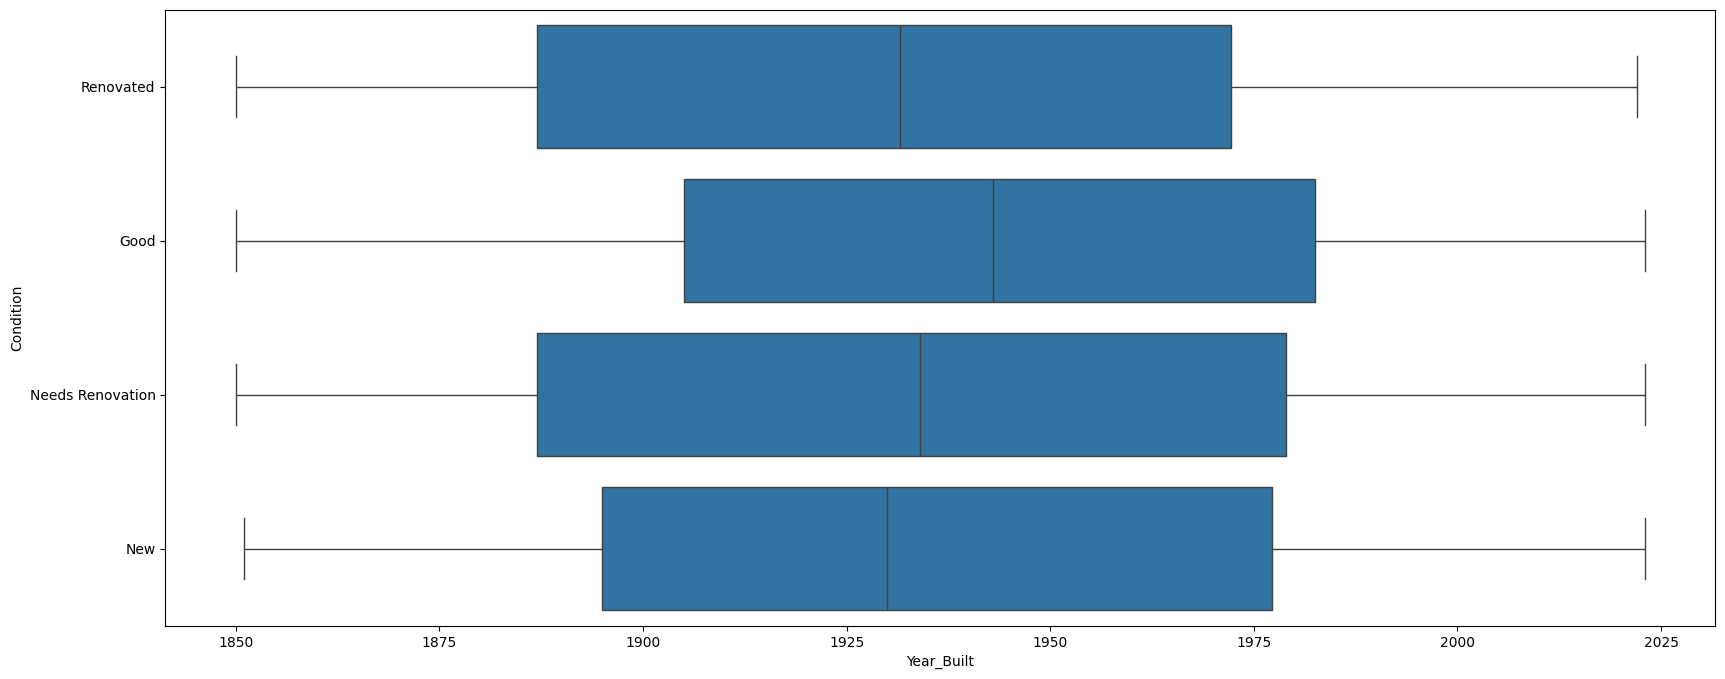

In [130]:
plt.figure(figsize=(20,8))
sns.boxplot(x='Year_Built', y='Condition',data=df)

plt.show()

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            1200 non-null   str    
 1   Arrondissement         1200 non-null   int64  
 2   Property_Type          1200 non-null   str    
 3   Size_sqm               1200 non-null   int64  
 4   Rooms                  1200 non-null   int64  
 5   Floor                  1200 non-null   int64  
 6   Year_Built             1200 non-null   int64  
 7   Condition              1200 non-null   str    
 8   Distance_to_Center_km  1200 non-null   float64
 9   Price_EUR              1200 non-null   float64
dtypes: float64(2), int64(5), str(3)
memory usage: 93.9 KB


In [132]:
import plotly.io as pio
pio.renderers.default = 'notebook'

In [134]:
import plotly.express as px

fig = px.histogram(df, x='Rooms', title='soni')
fig.show()

In [135]:
import klib

In [138]:
# nan qiymatlar yoq bolgani uchun ishlamadi 
klib.missingval_plot(df)

No missing values found in the dataset.


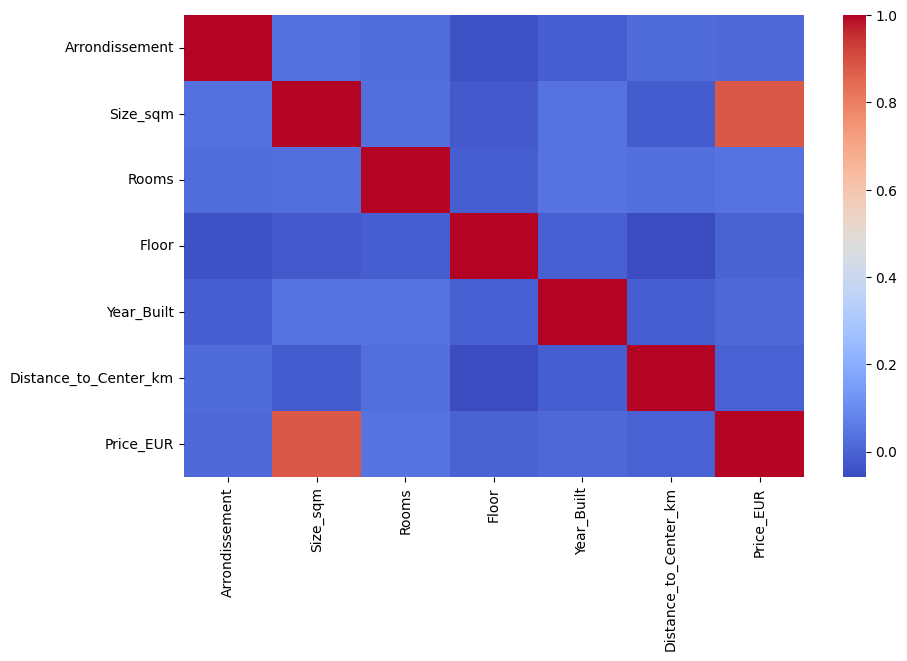

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=False)
plt.show()